Importing Libraries and Loading Dataset

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('ott_prediction.csv')
df

,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre,Popularity_Class
0,Kantara,2022,Rishab Shetty,"Rishab Shetty, Sapthami Gowda, Kishore Kumar G...",9.3,148,UA,Gross Unkown,Action,"Adventure, Drama",High
1,The Dark Knight,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",9.0,152,UA,$534.86M,Action,"Crime, Drama",High
2,The Lord of the Rings: The Return of the King,2003,Peter Jackson,"Elijah Wood, Viggo Mortensen, Ian McKellen, Or...",9.0,201,U,$377.85M,Action,"Adventure, Drama",High
3,Inception,2010,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",8.8,148,UA,$292.58M,Action,"Adventure, Sci-Fi",High
4,The Lord of the Rings: The Two Towers,2002,Peter Jackson,"Elijah Wood, Ian McKellen, Viggo Mortensen, Or...",8.8,179,UA,$342.55M,Action,"Adventure, Drama",High
...,...,...,...,...,...,...,...,...,...,...,...
5557,Disaster Movie,2008,"Directors:Jason Friedberg, Aaron Seltzer","Carmen Electra, Vanessa Lachey, Nicole Parker,...",1.9,87,PG-13,$14.19M,Comedy,Sci-Fi,Medium
5558,The Hottie & the Nottie,2008,Tom Putnam,"Paris Hilton, Joel David Moore, Christine Laki...",1.9,91,PG-13,$0.03M,Comedy,Romance,Medium
5559,From Justin to Kelly,2003,Robert Iscove,"Kelly Clarkson, Justin Guarini, Katherine Bail...",1.9,81,PG,$4.92M,Comedy,"Musical, Romance",Medium
5560,Superbabies: Baby Geniuses 2,2004,Bob Clark,"Jon Voight, Scott Baio, Vanessa Angel, Skyler ...",1.5,88,PG,$9.11M,Comedy,"Family, Sci-Fi",Low


Dataset Overview

In [95]:
df.shape

(5562, 11)

In [96]:
df.columns

Index(['Movie_Title', 'Year', 'Director', 'Actors', 'Rating', 'Runtime(Mins)',
       'Censor', 'Total_Gross', 'main_genre', 'side_genre',
       'Popularity_Class'],
      dtype='object')

In [97]:
df.dtypes

Movie_Title          object
Year                  int64
Director             object
Actors               object
Rating              float64
Runtime(Mins)         int64
Censor               object
Total_Gross          object
main_genre           object
side_genre           object
Popularity_Class     object
dtype: object

Sample Data Preview

In [98]:
df.head()

,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre,Popularity_Class
0,Kantara,2022,Rishab Shetty,"Rishab Shetty, Sapthami Gowda, Kishore Kumar G...",9.3,148,UA,Gross Unkown,Action,"Adventure, Drama",High
1,The Dark Knight,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",9.0,152,UA,$534.86M,Action,"Crime, Drama",High
2,The Lord of the Rings: The Return of the King,2003,Peter Jackson,"Elijah Wood, Viggo Mortensen, Ian McKellen, Or...",9.0,201,U,$377.85M,Action,"Adventure, Drama",High
3,Inception,2010,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",8.8,148,UA,$292.58M,Action,"Adventure, Sci-Fi",High
4,The Lord of the Rings: The Two Towers,2002,Peter Jackson,"Elijah Wood, Ian McKellen, Viggo Mortensen, Or...",8.8,179,UA,$342.55M,Action,"Adventure, Drama",High


In [99]:
df.tail()

,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre,Popularity_Class
5557,Disaster Movie,2008,"Directors:Jason Friedberg, Aaron Seltzer","Carmen Electra, Vanessa Lachey, Nicole Parker,...",1.9,87,PG-13,$14.19M,Comedy,Sci-Fi,Medium
5558,The Hottie & the Nottie,2008,Tom Putnam,"Paris Hilton, Joel David Moore, Christine Laki...",1.9,91,PG-13,$0.03M,Comedy,Romance,Medium
5559,From Justin to Kelly,2003,Robert Iscove,"Kelly Clarkson, Justin Guarini, Katherine Bail...",1.9,81,PG,$4.92M,Comedy,"Musical, Romance",Medium
5560,Superbabies: Baby Geniuses 2,2004,Bob Clark,"Jon Voight, Scott Baio, Vanessa Angel, Skyler ...",1.5,88,PG,$9.11M,Comedy,"Family, Sci-Fi",Low
5561,Cumali Ceber: Allah Seni Alsin,2017,Gökhan Gök,"Halil Söyletmez, Doga Konakoglu, Emre Keskin, ...",1.0,100,Not Rated,Gross Unkown,Comedy,Comedy,High


Checking and Handling Missing Values

In [100]:
df.isna().sum()

Movie_Title           0
Year                  0
Director              0
Actors                0
Rating                0
Runtime(Mins)         0
Censor              278
Total_Gross         445
main_genre            0
side_genre            0
Popularity_Class      0
dtype: int64

In [101]:
df['Censor'] = df['Censor'].fillna(df['Censor'].mode()[0])
df['Total_Gross'] = df['Total_Gross'].fillna('Unknown')


In [102]:
df.isna().sum()

Movie_Title         0
Year                0
Director            0
Actors              0
Rating              0
Runtime(Mins)       0
Censor              0
Total_Gross         0
main_genre          0
side_genre          0
Popularity_Class    0
dtype: int64

In [103]:
df.drop(['Movie_Title','Director','Actors','Total_Gross','side_genre','Rating'],axis=1,inplace=True)
df

,Year,Runtime(Mins),Censor,main_genre,Popularity_Class
0,2022,148,UA,Action,High
1,2008,152,UA,Action,High
2,2003,201,U,Action,High
3,2010,148,UA,Action,High
4,2002,179,UA,Action,High
...,...,...,...,...,...
5557,2008,87,PG-13,Comedy,Medium
5558,2008,91,PG-13,Comedy,Medium
5559,2003,81,PG,Comedy,Medium
5560,2004,88,PG,Comedy,Low


Target Variable Analysis

In [104]:
df['Popularity_Class'].value_counts()

Popularity_Class
High      1854
Medium    1854
Low       1854
Name: count, dtype: int64

Text(0, 0.5, 'Count')

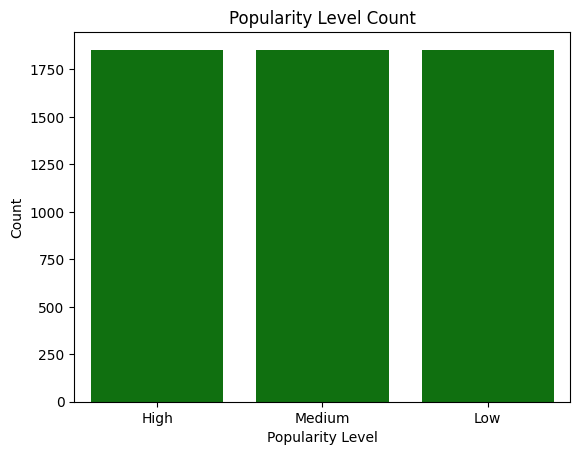

In [105]:
sns.countplot(x='Popularity_Class',data=df,color='g')
plt.title('Popularity Level Count')
plt.xlabel('Popularity Level')
plt.ylabel('Count')

Exploratory Data Analysis (EDA)

Text(0, 0.5, 'Runtime in Minutes')

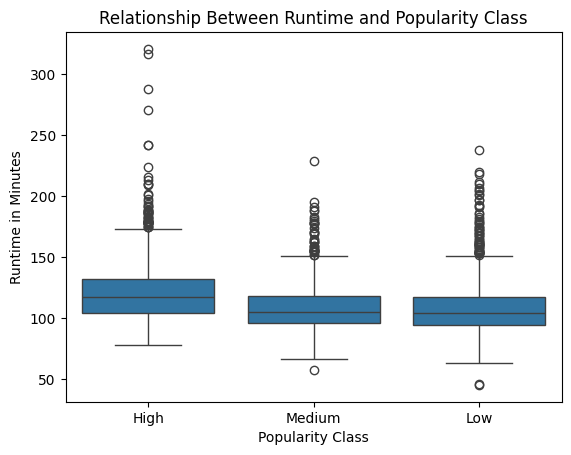

In [106]:
sns.boxplot(x='Popularity_Class',y='Runtime(Mins)',data=df)
plt.title('Relationship Between Runtime and Popularity Class')
plt.xlabel('Popularity Class')
plt.ylabel('Runtime in Minutes')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Action'),
  Text(1, 0, 'Animation'),
  Text(2, 0, 'Biography'),
  Text(3, 0, 'Adventure'),
  Text(4, 0, 'Western'),
  Text(5, 0, 'Drama'),
  Text(6, 0, 'Crime'),
  Text(7, 0, 'Comedy'),
  Text(8, 0, 'Horror'),
  Text(9, 0, 'Mystery'),
  Text(10, 0, 'Film-Noir'),
  Text(11, 0, 'Fantasy'),
  Text(12, 0, 'Musical')])

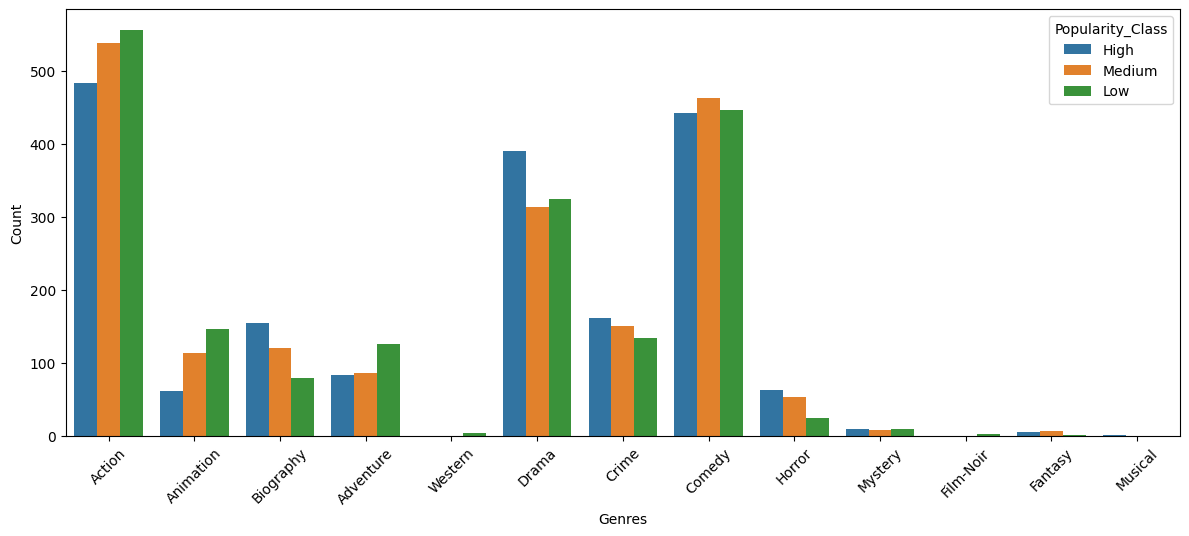

In [107]:
plt.figure(figsize=(12,5))
sns.countplot(x='main_genre',hue='Popularity_Class',data=df)
plt.tight_layout()
plt.ylabel('Count')
plt.xlabel('Genres')
plt.xticks(rotation=45)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'UA'),
  Text(1, 0, 'U'),
  Text(2, 0, 'A'),
  Text(3, 0, 'Not Rated'),
  Text(4, 0, 'R'),
  Text(5, 0, '18'),
  Text(6, 0, 'UA 16+'),
  Text(7, 0, 'PG'),
  Text(8, 0, 'PG-13'),
  Text(9, 0, 'U/A'),
  Text(10, 0, '7'),
  Text(11, 0, '16'),
  Text(12, 0, '(Banned)'),
  Text(13, 0, '13'),
  Text(14, 0, '12+'),
  Text(15, 0, 'UA 13+'),
  Text(16, 0, '15+'),
  Text(17, 0, 'All'),
  Text(18, 0, 'Unrated'),
  Text(19, 0, 'G'),
  Text(20, 0, 'UA 7+'),
  Text(21, 0, 'M/PG'),
  Text(22, 0, '18+'),
  Text(23, 0, 'NC-17')])

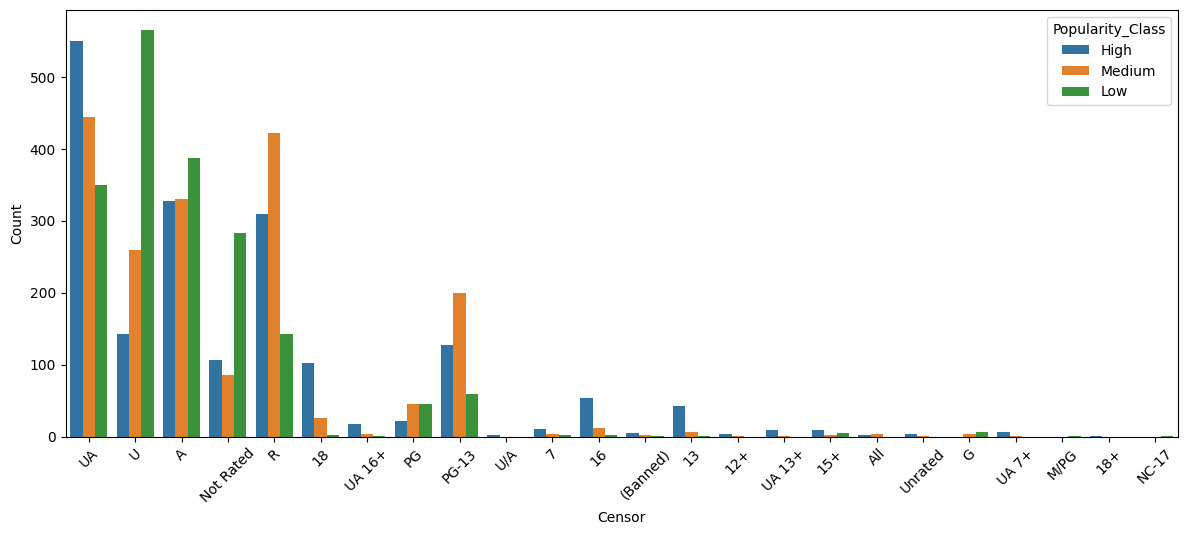

In [108]:
plt.figure(figsize=(12,5))
sns.countplot(x='Censor',hue='Popularity_Class',data=df)
plt.tight_layout()
plt.ylabel('Count')
plt.xlabel('Censor')
plt.xticks(rotation=45)

Data Preprocessing and Encoding

In [109]:
popularity_map = {'Low':0,'Medium':1,'High':2}
df['Popularity_Class'] = df['Popularity_Class'].map(popularity_map)
df

,Year,Runtime(Mins),Censor,main_genre,Popularity_Class
0,2022,148,UA,Action,2
1,2008,152,UA,Action,2
2,2003,201,U,Action,2
3,2010,148,UA,Action,2
4,2002,179,UA,Action,2
...,...,...,...,...,...
5557,2008,87,PG-13,Comedy,1
5558,2008,91,PG-13,Comedy,1
5559,2003,81,PG,Comedy,1
5560,2004,88,PG,Comedy,0


In [110]:
df.corr(numeric_only=True)

,Year,Runtime(Mins),Popularity_Class
Year,1.000000,0.022971,0.732748
Runtime(Mins),0.022971,1.000000,0.259400
Popularity_Class,0.732748,0.259400,1.000000


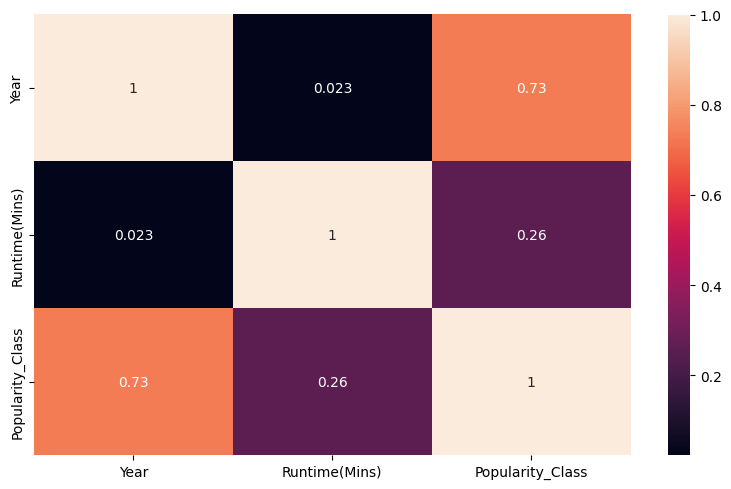

In [111]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.tight_layout()

In [112]:
df = pd.get_dummies(df,columns=['Censor'],drop_first=True,dtype=int)
df = pd.get_dummies(df,columns=['main_genre'],drop_first=True,dtype=int)
df

,Year,Runtime(Mins),Popularity_Class,Censor_12+,Censor_13,Censor_15+,Censor_16,Censor_18,Censor_18+,Censor_7,...,main_genre_Biography,main_genre_Comedy,main_genre_Crime,main_genre_Drama,main_genre_Fantasy,main_genre_Film-Noir,main_genre_Horror,main_genre_Musical,main_genre_Mystery,main_genre_Western
0,2022,148,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2008,152,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2003,201,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2010,148,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2002,179,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,2008,87,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5558,2008,91,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5559,2003,81,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5560,2004,88,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [113]:
x = df.drop(['Popularity_Class'],axis=1)
x

,Year,Runtime(Mins),Censor_12+,Censor_13,Censor_15+,Censor_16,Censor_18,Censor_18+,Censor_7,Censor_A,...,main_genre_Biography,main_genre_Comedy,main_genre_Crime,main_genre_Drama,main_genre_Fantasy,main_genre_Film-Noir,main_genre_Horror,main_genre_Musical,main_genre_Mystery,main_genre_Western
0,2022,148,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2008,152,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2003,201,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2010,148,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2002,179,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5557,2008,87,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5558,2008,91,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5559,2003,81,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5560,2004,88,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [114]:
y = df['Popularity_Class']
y

0       2
1       2
2       2
3       2
4       2
       ..
5557    1
5558    1
5559    1
5560    0
5561    2
Name: Popularity_Class, Length: 5562, dtype: int64

Train Test Split

In [115]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

Model Creation

In [116]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
y_pred

array([2, 2, 0, ..., 1, 1, 2], shape=(1669,))

Model Evaluation

In [117]:
names = ['Low','Medium','High']

In [118]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm = confusion_matrix(y_test,y_pred)
score = accuracy_score(y_test,y_pred)
report = classification_report(y_test,y_pred,target_names=names)
cm

array([[480,  60,   0],
       [ 60, 426,  96],
       [  1,  75, 471]])

Text(33.222222222222214, 0.5, 'True Label')

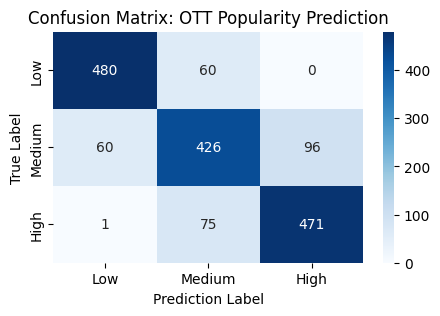

In [119]:
plt.figure(figsize=(5,3))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=names,yticklabels=names)
plt.title('Confusion Matrix: OTT Popularity Prediction')
plt.xlabel('Prediction Label')
plt.ylabel('True Label')


In [120]:
score

0.8250449370880767

In [121]:
print(report)

              precision    recall  f1-score   support

         Low       0.89      0.89      0.89       540
      Medium       0.76      0.73      0.75       582
        High       0.83      0.86      0.85       547

    accuracy                           0.83      1669
   macro avg       0.83      0.83      0.83      1669
weighted avg       0.82      0.83      0.82      1669



Hyper Parameter Tuning

In [122]:
# from sklearn.model_selection import GridSearchCV
# model1 = RandomForestClassifier()
# data = {'n_estimators': [500, 800, 1000],'max_depth': [15, 20, 25],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'max_features': ['sqrt', 'log2']}
# clf = GridSearchCV(model1,data,cv=5,scoring='accuracy',n_jobs=-1)
# clf.fit(x_train, y_train)

# print(clf.best_params_)

In [123]:
model2 = RandomForestClassifier(n_estimators=800,class_weight='balanced',max_depth=25,min_samples_leaf=1,min_samples_split=10,max_features='sqrt',random_state=42)
model2.fit(x_train,y_train)
y_pred1 = model2.predict(x_test)

In [124]:
cm1 = confusion_matrix(y_test,y_pred1)
score1 = accuracy_score(y_test,y_pred1)
report1 = classification_report(y_test,y_pred1,target_names=names)
cm1

array([[469,  71,   0],
       [ 47, 444,  91],
       [  4,  69, 474]])

Text(33.222222222222214, 0.5, 'True Label')

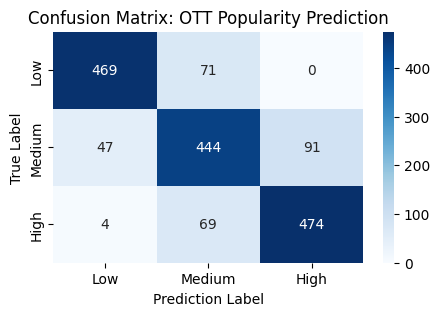

In [125]:
plt.figure(figsize=(5,3))
sns.heatmap(cm1,annot=True,fmt='d',cmap='Blues',xticklabels=names,yticklabels=names)
plt.title('Confusion Matrix: OTT Popularity Prediction')
plt.xlabel('Prediction Label')
plt.ylabel('True Label')

In [126]:
score1

0.8310365488316357

In [127]:
print(report1)

              precision    recall  f1-score   support

         Low       0.90      0.87      0.88       540
      Medium       0.76      0.76      0.76       582
        High       0.84      0.87      0.85       547

    accuracy                           0.83      1669
   macro avg       0.83      0.83      0.83      1669
weighted avg       0.83      0.83      0.83      1669



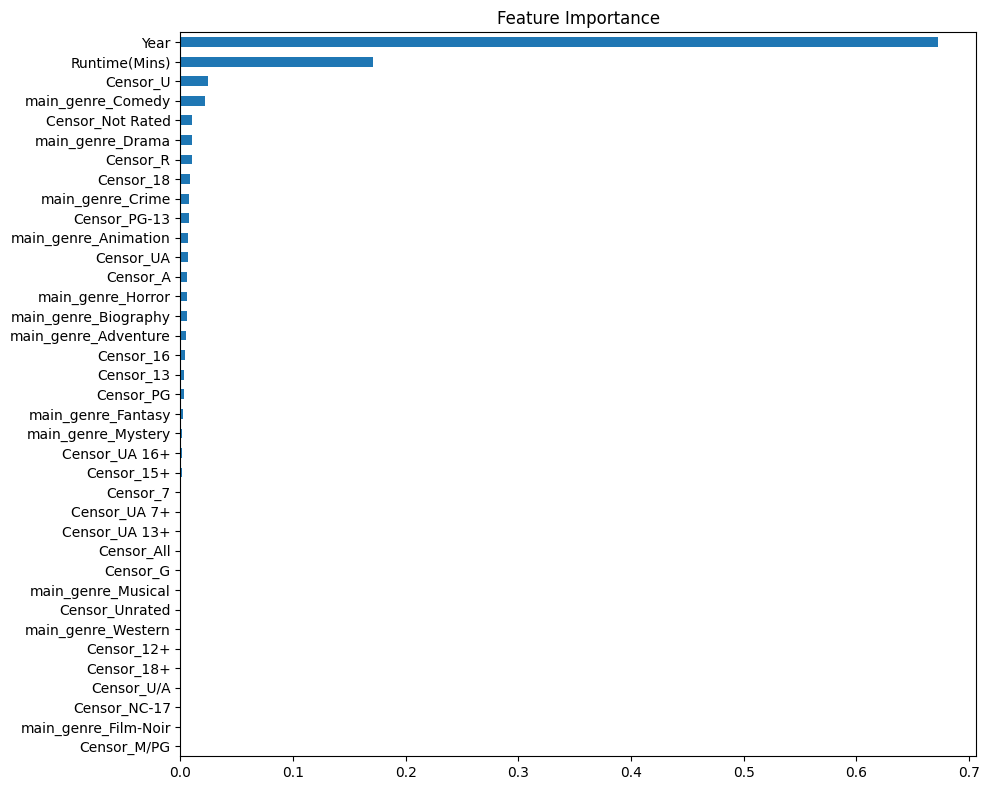

In [128]:
plt.figure(figsize=(10,8))
importances = pd.Series(model2.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()

Model Comparison

In [129]:
base_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred1)

print("Base Random Forest Accuracy:", base_accuracy)
print("Tuned Random Forest Accuracy:", tuned_accuracy)

Base Random Forest Accuracy: 0.8250449370880767
Tuned Random Forest Accuracy: 0.8310365488316357


In [130]:
comparison_df = pd.DataFrame({
    'Model': ['Base Random Forest', 'Tuned Random Forest'],
    'Accuracy': [base_accuracy, tuned_accuracy],
})

comparison_df

,Model,Accuracy
0,Base Random Forest,0.825045
1,Tuned Random Forest,0.831037


(0.0, 1.0)

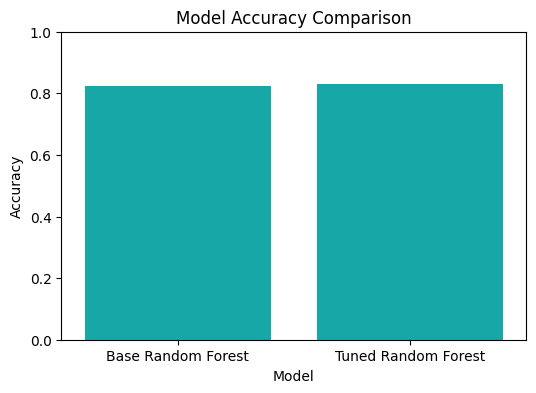

In [131]:
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=comparison_df,color='c')
plt.title('Model Accuracy Comparison')
plt.ylim(0,1)

Model Saving

In [132]:
# import pickle 
# # Save the model for Streamlit
# pickle.dump(model2, open('ott_imdb_model.pkl', 'wb'))

# # Save the columns to ensure consistency in Streamlit app
# pickle.dump(list(x.columns), open('model_columns.pkl', 'wb'))

In [133]:
import joblib
# Save the model
joblib.dump(model, 'ott_popularity_model.pkl')
# Save the specific column order to prevent "Only High" bias
joblib.dump(x_train.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']